# Python Exercises - Pandas

In [1]:
import pandas as pd

## Problem 1


Imagine three people, e.g. family, friends, cohort.

Create a pandas data frame called `cities_df` that contains the following columns:

* Cities - At least 5 cities in the US
* States - The states that those cities reside in
* Region - The region that those cities reside in (NW, SW, Midwest, etc.)
* Times_1 - The number of times person 1 has been to each city
* Times_2 - The number of times person 2 has been to each city
* Times_3 - The number of times person 3 has been to each city


In [2]:
cities = {'Cities'  : ['Los Angeles', 'Albuquerque', 'Chicago', 'Minneapolis', 'New York'],
          'States'  : ['California', 'New Mexico', 'Illinois', 'Minnesota', 'New York'],
          'Region'  : ['SW', 'SW', 'Midwest', 'Midwest', 'NE'],
          'Times_1' : [40, 50, 0, 3, 0],
          'Times_2' : [20, 80, 2, 15, 30],
          'Times_3' : [20, 60, 0, 80, 2]}
cities

{'Cities': ['Los Angeles',
  'Albuquerque',
  'Chicago',
  'Minneapolis',
  'New York'],
 'States': ['California', 'New Mexico', 'Illinois', 'Minnesota', 'New York'],
 'Region': ['SW', 'SW', 'Midwest', 'Midwest', 'NE'],
 'Times_1': [40, 50, 0, 3, 0],
 'Times_2': [20, 80, 2, 15, 30],
 'Times_3': [20, 60, 0, 80, 2]}

In [3]:
cities_df = pd.DataFrame(cities)

In [4]:
cities_df

,Cities,States,Region,Times_1,Times_2,Times_3
0,Los Angeles,California,SW,40,20,20
1,Albuquerque,New Mexico,SW,50,80,60
2,Chicago,Illinois,Midwest,0,2,0
3,Minneapolis,Minnesota,Midwest,3,15,80
4,New York,New York,NE,0,30,2


## Problem 2


Use the `.describe()` and `.info()` methods on your data frame


In [5]:
cities_df.describe()

,Times_1,Times_2,Times_3
count,5.000000,5.000000,5.000000
mean,18.600000,29.400000,32.400000
std,24.388522,30.029985,35.899861
min,0.000000,2.000000,0.000000
25%,0.000000,15.000000,2.000000
50%,3.000000,20.000000,20.000000
75%,40.000000,30.000000,60.000000
max,50.000000,80.000000,80.000000


In [6]:
cities_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Cities   5 non-null      object
 1   States   5 non-null      object
 2   Region   5 non-null      object
 3   Times_1  5 non-null      int64 
 4   Times_2  5 non-null      int64 
 5   Times_3  5 non-null      int64 
dtypes: int64(3), object(3)
memory usage: 372.0+ bytes


## Problem 3


Use indexing to access the Cities column

In [7]:
cities_df['Cities']

,Cities
0,Los Angeles
1,Albuquerque
2,Chicago
3,Minneapolis
4,New York


## Problem 4


Create a new column called `Total_Times` that contains the total number of times all team members have been to each city.

In [8]:
cities_df_backup = cities_df.copy()

In [9]:
cities_df['Total_Times'] = cities_df['Times_1'] + cities_df['Times_2'] + cities_df['Times_3']
cities_df

,Cities,States,Region,Times_1,Times_2,Times_3,Total_Times
0,Los Angeles,California,SW,40,20,20,80
1,Albuquerque,New Mexico,SW,50,80,60,190
2,Chicago,Illinois,Midwest,0,2,0,2
3,Minneapolis,Minnesota,Midwest,3,15,80,98
4,New York,New York,NE,0,30,2,32


## Problem 5


Use indexing to access the cities that have been travelled to more than two times.

In [10]:
filter = ( cities_df['Total_Times'] > 2 )
cities_df[filter]

,Cities,States,Region,Times_1,Times_2,Times_3,Total_Times
0,Los Angeles,California,SW,40,20,20,80
1,Albuquerque,New Mexico,SW,50,80,60,190
3,Minneapolis,Minnesota,Midwest,3,15,80,98
4,New York,New York,NE,0,30,2,32


## Problem 6


Make a bar plot with `Cities` on the x axis and `Total_Times` on the y axis.

<Axes: xlabel='Cities'>

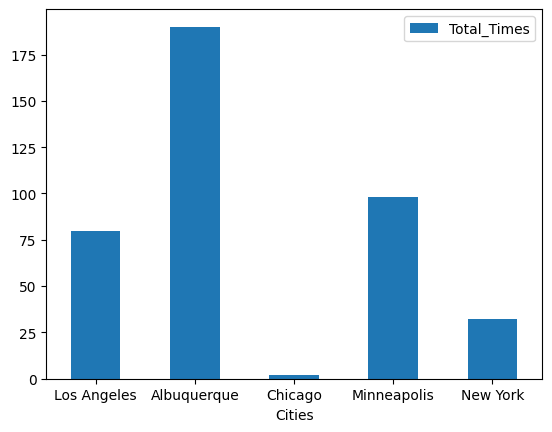

In [11]:
cities_df.plot(x='Cities', y='Total_Times', kind='bar', rot=0)

## Problem 7


Drop the 'Total_Times' column from your data frame.

In [12]:
cities_df.drop(labels ='Total_Times', axis = "columns", inplace = True)
cities_df

,Cities,States,Region,Times_1,Times_2,Times_3
0,Los Angeles,California,SW,40,20,20
1,Albuquerque,New Mexico,SW,50,80,60
2,Chicago,Illinois,Midwest,0,2,0
3,Minneapolis,Minnesota,Midwest,3,15,80
4,New York,New York,NE,0,30,2


## Problem 8


Restructure your data frame using the pandas `.melt()` method. In the `.melt()` method, specify `id_vars = ['Cities', 'States', 'Region']`. Save the melted data frame as a new variable called `cities_df_melted`. Print out `cities_df_melted`.

> Note: make sure to read through the documentation for the `.melt()` method to understand what the method does.

In [13]:
cities_df_melted = cities_df.melt(id_vars = ['Cities', 'States', 'Region'])
cities_df_melted

,Cities,States,Region,variable,value
0,Los Angeles,California,SW,Times_1,40
1,Albuquerque,New Mexico,SW,Times_1,50
2,Chicago,Illinois,Midwest,Times_1,0
3,Minneapolis,Minnesota,Midwest,Times_1,3
4,New York,New York,NE,Times_1,0
5,Los Angeles,California,SW,Times_2,20
6,Albuquerque,New Mexico,SW,Times_2,80
7,Chicago,Illinois,Midwest,Times_2,2
8,Minneapolis,Minnesota,Midwest,Times_2,15
9,New York,New York,NE,Times_2,30


In [23]:
cities_df_melted_alt = cities_df_melted.sort_values(by=['Cities', 'value'])
cities_df_melted_alt

,Cities,States,Region,variable,value
1,Albuquerque,New Mexico,SW,Times_1,50
11,Albuquerque,New Mexico,SW,Times_3,60
6,Albuquerque,New Mexico,SW,Times_2,80
2,Chicago,Illinois,Midwest,Times_1,0
12,Chicago,Illinois,Midwest,Times_3,0
7,Chicago,Illinois,Midwest,Times_2,2
5,Los Angeles,California,SW,Times_2,20
10,Los Angeles,California,SW,Times_3,20
0,Los Angeles,California,SW,Times_1,40
3,Minneapolis,Minnesota,Midwest,Times_1,3


<Axes: xlabel='Cities'>

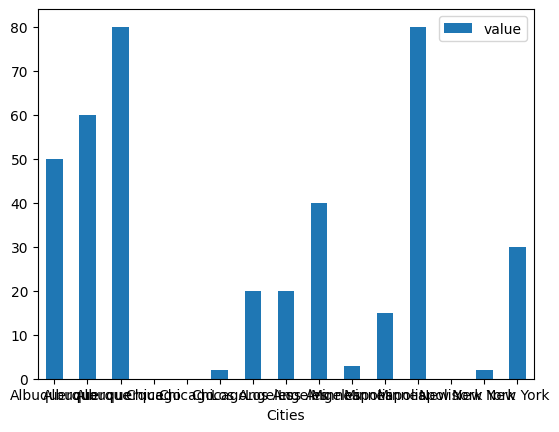

In [24]:
cities_df_melted_alt.plot(x='Cities', y='value', kind='bar', rot=0)

## Problem 9


Use the seaborn `barplot()` function to create a barplot of `cities_df_melted` with `Cities` on the x axis, `value` on the y axis and the hue parameter set to `variable`.

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='Cities', ylabel='value'>

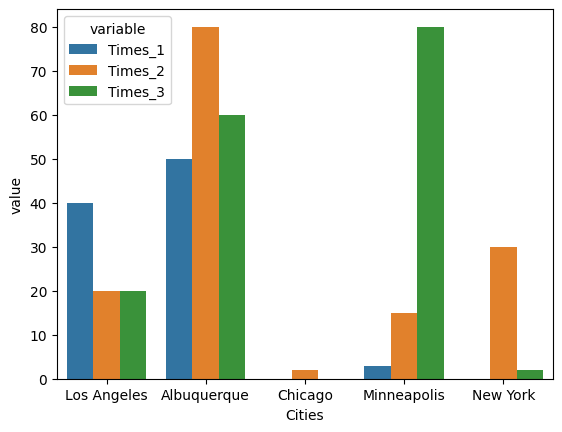

In [20]:
sns.barplot(
    data=cities_df_melted,
    x="Cities",
    y="value",
    hue="variable",
)

In [16]:
pd.DataFrame.melt?